# 粘液栓中心点与线段可视化

在裁剪后的肺部 CT (`lung_image.nii.gz`) 上叠加 Mask 标注中心点和标注线段（[NDir]/[NDe]）。

- 数据来源: `annotation_points_cropped.txt`（裁剪后体素坐标）
- CT 图像: `lung_image.nii.gz`
- 线段格式: `x1 y1 z1 | x2 y2 z2`（起点 → 终点）

In [1]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ipywidgets import interact, IntSlider, Dropdown, fixed
from pathlib import Path
import re

DATA_DIR = "/data/Mucus_data/E0001425_20100927"
TXT_PATH = f"{DATA_DIR}/annotation_points_cropped.txt"
NII_PATH = f"{DATA_DIR}/lung_image.nii.gz"
NII1_PATH = f"{DATA_DIR}/image.nii.gz"

print(f"CT: {NII_PATH}")
print(f"Points: {TXT_PATH}")

CT: /data/Mucus_data/E0001425_20100927/lung_image.nii.gz
Points: /data/Mucus_data/E0001425_20100927/annotation_points_cropped.txt


In [2]:
def parse_annotation_txt(txt_path):
    """解析 annotation_points_cropped.txt，返回 mask 中心点和线段。

    Returns:
        masks: [{"name": str, "x": float, "y": float, "z": float}, ...]
        segments: [{"name": str, "x1": float, "y1": float, "z1": float,
                     "x2": float, "y2": float, "z2": float}, ...]
    """
    masks = []
    segments = []
    section = None
    with open(txt_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            if line.startswith("["):
                section = line.strip("[]")
                continue
            if section == "Mask":
                parts = line.split()
                masks.append({
                    "name": parts[0],
                    "x": float(parts[1]),
                    "y": float(parts[2]),
                    "z": float(parts[3]),
                })
            elif section in ("1Dir", "1De", "2Dir", "2De", "3Dir", "3De",
                             "4Dir", "4De", "5Dir", "5De", "6Dir", "6De",
                             "7Dir", "7De", "8Dir", "8De"):
                # 线段格式: x1 y1 z1 | x2 y2 z2
                parts = line.split("|")
                p1 = parts[0].strip().split()
                p2 = parts[1].strip().split()
                segments.append({
                    "name": section,
                    "mask_id": int(section[0]),  # 对应的 Mask 编号
                    "type": section[1:],          # "Dir" 或 "De"
                    "x1": float(p1[0]), "y1": float(p1[1]), "z1": float(p1[2]),
                    "x2": float(p2[0]), "y2": float(p2[1]), "z2": float(p2[2]),
                })
    return masks, segments


# 加载数据
nii = nib.load(NII_PATH)
ct_data = nii.get_fdata().astype(np.float32)
X_MAX, Y_MAX, Z_MAX = ct_data.shape  # (x, y, z)
print(f"CT shape (x, y, z): {ct_data.shape}")

mask_points_all, segments_all = parse_annotation_txt(TXT_PATH)

# 检查 Mask 点是否在裁剪 CT 范围内
mask_points = []
mask_points_out = []
for m in mask_points_all:
    x_ok = 0 <= m["x"] < X_MAX
    y_ok = 0 <= m["y"] < Y_MAX
    z_ok = 0 <= m["z"] < Z_MAX
    if x_ok and y_ok and z_ok:
        mask_points.append(m)
    else:
        mask_points_out.append(m)

print(f"Mask 中心点: {len(mask_points_all)} 个 (有效 {len(mask_points)})")
print(f"线段: {len(segments_all)} 条")
for seg in segments_all:
    print(f"  {seg['name']}: ({seg['x1']:.0f},{seg['y1']:.0f},{seg['z1']:.0f}) → ({seg['x2']:.0f},{seg['y2']:.0f},{seg['z2']:.0f})")

CT shape (x, y, z): (320, 213, 622)
Mask 中心点: 8 个 (有效 8)
线段: 0 条


In [3]:
ct_data = ct_data.transpose(2,1,0)

In [4]:
# HU 窗宽窗位设置
WL, WW = -600, 1600  # 肺窗
vmin = WL - WW // 2
vmax = WL + WW // 2
print(f"Window: WL={WL}, WW={WW} → range [{vmin}, {vmax}]")

Window: WL=-600, WW=1600 → range [-1400, 200]


## 交互式轴位（Axial）切面浏览

拖动滑块切换 Z 轴切面，红色圆点标出当前切面附近 ±5 范围内的 mask 中心，蓝绿色 X 标出线段与当前切面的交点。

In [5]:
def segment_slice_intersection(seg, slice_z, axis="z"):
    """计算线段与指定切面的交点。

    axis="z": 线段与 Z=slice_z 平面的交点 → 返回 (x, y) 或 None
    axis="y": 线段与 Y=slice_y 平面的交点 → 返回 (x, z) 或 None
    axis="x": 线段与 X=slice_x 平面的交点 → 返回 (y, z) 或 None

    只有当线段两端分别位于切面两侧（或恰好在切面上）时才返回交点。
    """
    if axis == "z":
        z1, z2 = seg["z1"], seg["z2"]
        v1, v2 = (seg["x1"], seg["y1"]), (seg["x2"], seg["y2"])
        coord1, coord2 = z1, z2
    elif axis == "y":
        z1, z2 = seg["y1"], seg["y2"]
        v1, v2 = (seg["x1"], seg["z1"]), (seg["x2"], seg["z2"])
        coord1, coord2 = z1, z2
    elif axis == "x":
        z1, z2 = seg["x1"], seg["x2"]
        v1, v2 = (seg["y1"], seg["z1"]), (seg["y2"], seg["z2"])
        coord1, coord2 = z1, z2

    if coord1 == coord2:
        return None

    t = (slice_z - coord1) / (coord2 - coord1)
    if t < 0 or t > 1:
        return None

    x = v1[0] + t * (v2[0] - v1[0])
    y = v1[1] + t * (v2[1] - v1[1])
    return (x, y)


def plot_axial_with_points(slice_z, z_tolerance=5):
    """绘制轴位 (axial) 切面，叠加附近 mask 中心点和穿过该切面的线段交点。
    ct_data 维度: [z, y, x]; ct_data[slice_z] 形状 (y, x),
    imshow axis0=Y(垂直), axis1=X(水平), origin="lower" 使 Y 向上递增。
    """
    z_max = ct_data.shape[0] - 1
    slice_z = max(0, min(slice_z, z_max))

    img = ct_data[slice_z]          # (y, x)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.imshow(img, cmap="gray", vmin=vmin, vmax=vmax, origin="lower")

    # Mask 中心点（红色圆点）
    nearby = [m for m in mask_points if abs(m["z"] - slice_z) <= z_tolerance]
    for m in nearby:
        ax.plot(m["x"], m["y"], "o", markersize=6,
                markerfacecolor="red", markeredgecolor="red")
        ax.annotate(m["name"], (m["x"] + 2, m["y"] + 2),
                    color="red", fontsize=7, weight="bold")

    # 线段交点（蓝绿色 X）
    for seg in segments_all:
        pt = segment_slice_intersection(seg, slice_z, axis="z")
        if pt is not None:
            x, y = pt
            if 0 <= x < X_MAX and 0 <= y < Y_MAX:
                ax.plot(x, y, "x", markersize=10,
                        markeredgecolor="cyan", markeredgewidth=2)
                ax.annotate(seg["name"], (x + 2, y - 4),
                            color="cyan", fontsize=6)

    all_in_view = [m for m in mask_points if 0 <= m["z"] <= z_max]
    ax.set_title(f"Axial (Z={slice_z}/{z_max}) | {len(nearby)} point(s) nearby | "
                 f"{len(segments_all)} segments | {len(all_in_view)} masks total")
    ax.set_xlabel("X (voxel)")
    ax.set_ylabel("Y (voxel)")
    plt.tight_layout()
    plt.show()


z_slider = IntSlider(value=int(ct_data.shape[0] // 2), min=0, max=ct_data.shape[0] - 1,
                     step=1, description="Z slice:", continuous_update=False)
interact(plot_axial_with_points, slice_z=z_slider, z_tolerance=fixed(5))

interactive(children=(IntSlider(value=311, continuous_update=False, description='Z slice:', max=621), Output()…

<function __main__.plot_axial_with_points(slice_z, z_tolerance=5)>

## 三视图（Axial / Coronal / Sagittal）

以每个 mask 中心点为焦点，显示三视图切面，同时叠加该 mask 对应的线段（[Ndir] 和 [NDe]）。

- 🔴 **红色圆点**: Mask 中心点
- 🟦 **青色方块** (■): 线段起点
- 🟨 **黄色菱形** (◆): 线段终点
- 🟦 **青色连线**: 线段在切面上的投影
- 🟢 **绿色 X**: 线段与当前切面的交点

In [6]:
def plot_three_views(mask_name):
    """以指定 mask 为中心，显示 Axial / Coronal / Sagittal 三视图，
    同时叠加该 mask 对应的线段（[Ndir] 和 [NDe]）。

    ct_data 维度: [z, y, x]
    - Axial: ct_data[z, :, :] → (y, x), axis0=Y(垂直), axis1=X(水平)
    - Coronal: ct_data[:, y, :] → (z, x), axis0=Z(垂直), axis1=X(水平)
    - Sagittal: ct_data[:, :, x] → (z, y), axis0=Z(垂直), axis1=Y(水平)
    origin="lower" 使垂直轴向上递增。
    """
    target = next((m for m in mask_points if m["name"] == mask_name), None)
    if target is None:
        target = next((m for m in mask_points_out if m["name"] == mask_name), None)
        if target:
            print(f"⚠ {mask_name} 坐标 ({target['x']:.0f}, {target['y']:.0f}, {target['z']:.0f}) 超出CT范围，无法显示")
        else:
            print(f"Mask {mask_name} not found")
        return

    cx_raw, cy_raw, cz_raw = target["x"], target["y"], target["z"]
    cx = int(np.clip(cx_raw, 0, X_MAX - 1))
    cy = int(np.clip(cy_raw, 0, Y_MAX - 1))
    cz = int(np.clip(cz_raw, 0, Z_MAX - 1))

    # 找到该 mask 对应的线段
    mask_num = int(mask_name.replace("Mask", ""))
    related_segs = [s for s in segments_all if s["mask_id"] == mask_num]

    warnings = []
    if cx_raw != cx: warnings.append(f"X clamped {cx_raw:.0f}→{cx}")
    if cy_raw != cy: warnings.append(f"Y clamped {cy_raw:.0f}→{cy}")
    if cz_raw != cz: warnings.append(f"Z clamped {cz_raw:.0f}→{cz}")

    fig, axes = plt.subplots(1, 3, figsize=(21, 7))

    # --- Axial (Z切面): ct_data[cz] → (y, x), axis0=Y, axis1=X ---
    ax = axes[0]
    img_axial = ct_data[cz]           # (y, x)，不需要 .T
    ax.imshow(img_axial, cmap="gray", vmin=vmin, vmax=vmax, origin="lower")
    # Mask 中心点
    ax.plot(cx, cy, "o", markersize=16, markerfacecolor="none",
            markeredgecolor="red", markeredgewidth=3)
    ax.plot(cx, cy, "o", markersize=4, markerfacecolor="red", markeredgecolor="red")
    for seg in related_segs:
        ax.plot([seg["x1"], seg["x2"]], [seg["y1"], seg["y2"]],
                "-", color="cyan", linewidth=2, alpha=0.7)
        ax.plot(seg["x1"], seg["y1"], "s", markersize=5,
                markerfacecolor="cyan", markeredgecolor="white", markeredgewidth=0.5)
        ax.plot(seg["x2"], seg["y2"], "D", markersize=5,
                markerfacecolor="yellow", markeredgecolor="white", markeredgewidth=0.5)
        pt = segment_slice_intersection(seg, cz, axis="z")
        if pt is not None:
            ax.plot(pt[0], pt[1], "X", markersize=14,
                    markerfacecolor="none", markeredgecolor="lime", markeredgewidth=2)
    ax.set_title(f"Axial (Z={cz})")
    ax.set_xlabel("X"); ax.set_ylabel("Y")
 
    # --- Coronal (Y切面): ct_data[:, cy] → (z, x), axis0=Z, axis1=X ---
    ax = axes[1]
    img_coronal = ct_data[:, cy, :]   # (z, x)，不需要 .T
    ax.imshow(img_coronal, cmap="gray", vmin=vmin, vmax=vmax, origin="lower")
    ax.plot(cx, cz, "o", markersize=16, markerfacecolor="none",
            markeredgecolor="red", markeredgewidth=3)
    ax.plot(cx, cz, "o", markersize=4, markerfacecolor="red", markeredgecolor="red")
    for seg in related_segs:
        ax.plot([seg["x1"], seg["x2"]], [seg["z1"], seg["z2"]],
                "-", color="cyan", linewidth=2, alpha=0.7)
        ax.plot(seg["x1"], seg["z1"], "s", markersize=5,
                markerfacecolor="cyan", markeredgecolor="white", markeredgewidth=0.5)
        ax.plot(seg["x2"], seg["z2"], "D", markersize=5,
                markerfacecolor="yellow", markeredgecolor="white", markeredgewidth=0.5)
        pt = segment_slice_intersection(seg, cy, axis="y")
        if pt is not None:
            ax.plot(pt[0], pt[1], "X", markersize=14,
                    markerfacecolor="none", markeredgecolor="lime", markeredgewidth=2)
    ax.set_title(f"Coronal (Y={cy})")
    ax.set_xlabel("X"); ax.set_ylabel("Z")

    # --- Sagittal (X切面): ct_data[:, :, cx] → (z, y), axis0=Z, axis1=Y ---
    ax = axes[2]
    img_sagittal = ct_data[:, :, cx]  # (z, y)，不需要 .T
    ax.imshow(img_sagittal, cmap="gray", vmin=vmin, vmax=vmax, origin="lower")
    ax.plot(cy, cz, "o", markersize=16, markerfacecolor="none",
            markeredgecolor="red", markeredgewidth=3)
    ax.plot(cy, cz, "o", markersize=4, markerfacecolor="red", markeredgecolor="red")
    for seg in related_segs:
        ax.plot([seg["y1"], seg["y2"]], [seg["z1"], seg["z2"]],
                "-", color="cyan", linewidth=2, alpha=0.7)
        ax.plot(seg["y1"], seg["z1"], "s", markersize=5,
                markerfacecolor="cyan", markeredgecolor="white", markeredgewidth=0.5)
        ax.plot(seg["y2"], seg["z2"], "D", markersize=5,
                markerfacecolor="yellow", markeredgecolor="white", markeredgewidth=0.5)
        pt = segment_slice_intersection(seg, cx, axis="x")
        if pt is not None:
            ax.plot(pt[0], pt[1], "X", markersize=14,
                    markerfacecolor="none", markeredgecolor="lime", markeredgewidth=2)

    ax.set_title(f"Sagittal (X={cx})")
    ax.set_xlabel("Y"); ax.set_ylabel("Z")

    title = f"{mask_name} — cropped voxel ({cx_raw:.0f}, {cy_raw:.0f}, {cz_raw:.0f})"
    if warnings:
        title += f"  ⚠ {'; '.join(warnings)}"
    title += f"\nSegments: {[s['name'] for s in related_segs]}"
    fig.suptitle(title, fontsize=14, weight="bold", color="red")
    plt.tight_layout()
    plt.show()


mask_names_valid = [m["name"] for m in mask_points]
if mask_names_valid:
    name_dropdown = Dropdown(options=mask_names_valid, value=mask_names_valid[0], description="Mask:")
    interact(plot_three_views, mask_name=name_dropdown)
else:
    print("⚠ 没有有效范围内的 Mask 点")

interactive(children=(Dropdown(description='Mask:', options=('Mask1', 'Mask2', 'Mask3', 'Mask4', 'Mask5', 'Mas…

## 汇总：所有 Mask 在各自轴位切面上的位置

每个 mask 显示其中心点所在轴位切面，并叠加对应的标注线段（Dir/De 投影及交点）。

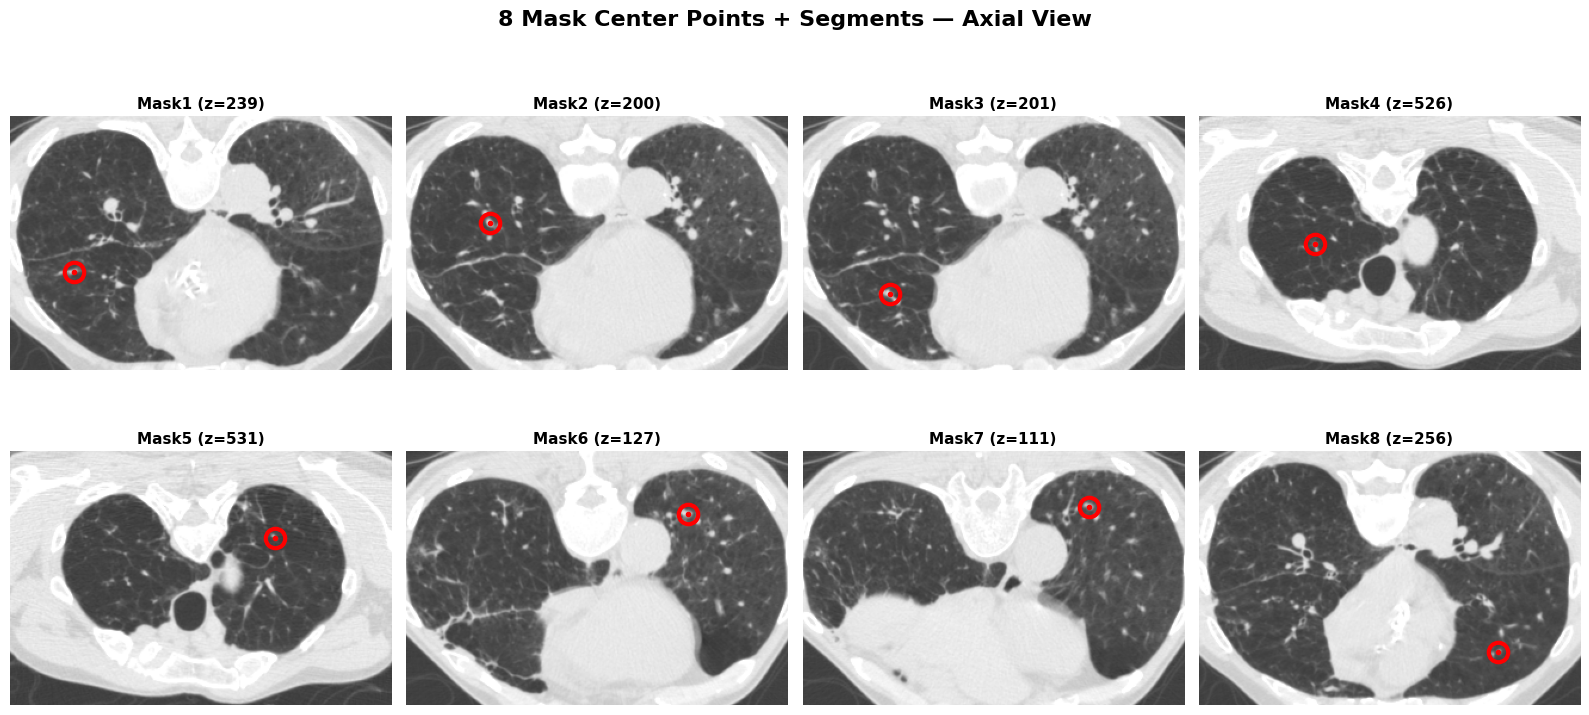

In [7]:
valid = mask_points  # 只使用有效范围内的点
n_masks = len(valid)
if n_masks == 0:
    print("⚠ 没有有效范围内的 Mask 点可显示")
else:
    cols = min(4, n_masks)
    rows = (n_masks + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    if n_masks == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, m in enumerate(valid):
        ax = axes[i]
        z = int(m["z"])

        # ct_data[z] → (y, x), 不需要 .T
        img = ct_data[z, :, :]          # (y, x), axis0=Y, axis1=X
        ax.imshow(img, cmap="gray", vmin=vmin, vmax=vmax, origin="lower")

        # Mask 中心点
        ax.plot(m["x"], m["y"], "o", markersize=14, markerfacecolor="none",
                markeredgecolor="red", markeredgewidth=3)
        ax.plot(m["x"], m["y"], "o", markersize=3, markerfacecolor="red",
                markeredgecolor="red")

        # 该 mask 对应的线段
        mask_num = int(m["name"].replace("Mask", ""))
        for seg in segments_all:
            if seg["mask_id"] != mask_num:
                continue
            # 线段投影
            ax.plot([seg["x1"], seg["x2"]], [seg["y1"], seg["y2"]],
                    "-", color="cyan", linewidth=1.5, alpha=0.6)
            ax.plot(seg["x1"], seg["y1"], "s", markersize=3,
                    markerfacecolor="cyan", markeredgecolor="white", markeredgewidth=0.3)
            ax.plot(seg["x2"], seg["y2"], "D", markersize=3,
                    markerfacecolor="yellow", markeredgecolor="white", markeredgewidth=0.3)
            # 与当前 Z 切面的交点
            pt = segment_slice_intersection(seg, z, axis="z")
            if pt is not None:
                ax.plot(pt[0], pt[1], "X", markersize=10,
                        markerfacecolor="none", markeredgecolor="lime", markeredgewidth=1.5)

        ax.set_title(f"{m['name']} (z={z})", fontsize=11, weight="bold")
        ax.axis("off")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    title = f"{len(valid)} Mask Center Points + Segments — Axial View"
    if mask_points_out:
        title += f"  ({len(mask_points_out)} out of range skipped)"
    fig.suptitle(title, fontsize=16, weight="bold")
    plt.tight_layout()
    plt.show()